In [1]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)


In [2]:
def load_array(data_arrays, batch_size, is_train=True):  #@save
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [3]:
next(iter(data_iter))


[tensor([[ 0.5752,  0.6880],
         [-0.2893, -1.3027],
         [-1.3661,  0.2261],
         [ 2.1055, -0.6314],
         [ 0.1289, -0.0255],
         [ 0.1140,  0.2856],
         [-1.3707,  0.3292],
         [-0.4415, -0.7116],
         [-1.2245, -1.6063],
         [-0.7940, -0.3567]]),
 tensor([[ 3.0200],
         [ 8.0360],
         [ 0.6955],
         [10.5652],
         [ 4.5353],
         [ 3.4583],
         [ 0.3451],
         [ 5.7402],
         [ 7.2247],
         [ 3.8163]])]

In [4]:
# nn是神经网络的缩写
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

In [5]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [6]:
loss = nn.MSELoss()

In [12]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [13]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000096
epoch 2, loss 0.000096
epoch 3, loss 0.000095


In [14]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([-9.3222e-05, -7.1359e-04])
b的估计误差： tensor([-0.0001])


In [1]:
import torch
# 每个元素的均值和标准差不同
a = torch.normal(mean=torch.arange(1., 6.), std=torch.arange(1, 0, -0.2))
# 所有元素均值为0.5，标准差不同
b = torch.normal(mean=0.5, std=torch.arange(1., 6.))
print(a)
print(b)

print(a.shape)
print(b.shape)

tensor([0.9237, 3.5122, 3.3512, 3.8883, 4.9718])
tensor([ 0.1785, -1.2615, -3.5170,  4.1358,  2.5712])
torch.Size([5])
torch.Size([5])


In [2]:
import torch
a = torch.randn(3, 4)
b = torch.randn(4, 5)
result = torch.matmul(a, b)  # 结果形状为 (3, 5)

print(a)
print(b)
print(result)
print(result.shape)

tensor([[-1.0656,  1.4537,  0.3967, -1.1208],
        [ 0.3528, -0.7527, -1.7306,  0.0707],
        [ 1.5787, -0.3392,  1.3238,  0.9475]])
tensor([[-1.1823, -0.7765,  0.5056, -2.6154,  1.6911],
        [ 1.5741,  2.3163,  0.9215, -0.6042, -1.2225],
        [ 1.6767, -0.5537,  0.7035, -0.8086,  0.3355],
        [ 0.1778, -2.2227,  0.8329, -1.1694,  0.7326]])
tensor([[ 4.0139,  6.4663,  0.1463,  2.8986, -4.2673],
        [-4.4912, -1.2164, -1.6739,  0.8486,  0.9881],
        [-0.0125, -4.8504,  2.2061, -6.1024,  4.2227]])
torch.Size([3, 5])


In [3]:
import torch
# 每个元素的均值和标准差不同
a = torch.normal(0,1,(5,1))
# 所有元素均值为0.5，标准差不同
# b = torch.normal(mean=0.5, std=torch.arange(1., 6.))
print(a)
# print(b)

print(a.shape)
# print(b.shape)

tensor([[ 0.5279],
        [ 0.1720],
        [ 0.8404],
        [ 0.9825],
        [-1.6648]])
torch.Size([5, 1])


In [9]:
import torch
w = torch.tensor([2, -3.4])
print(w)
print(w.shape)
print(len(w))
X = torch.normal(0, 1, (5, len(w)))
print(X)
print(X.shape)


tensor([ 2.0000, -3.4000])
torch.Size([2])
2
tensor([[ 1.8752, -1.2384],
        [ 1.8776, -1.8276],
        [-0.9510, -1.5877],
        [ 0.9460, -0.8484],
        [-0.4848, -0.2010]])
torch.Size([5, 2])


In [12]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [13]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [15]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([ 1.9657, -0.1899]) 
label: tensor([8.7751])


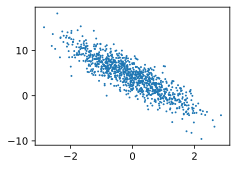

In [18]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [21]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [22]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.9955, -0.1439],
        [-0.2845, -0.7928],
        [ 0.6587,  0.5264],
        [-0.0609,  1.5262],
        [-2.1491, -0.4103],
        [ 1.9402,  0.5839],
        [-0.4282, -1.7923],
        [-1.3251, -1.2733],
        [ 0.1397,  0.2179],
        [-0.9853,  1.8027]]) 
 tensor([[ 2.6998],
        [ 6.3382],
        [ 3.7399],
        [-1.1054],
        [ 1.2944],
        [ 6.0940],
        [ 9.4193],
        [ 5.8864],
        [ 3.7505],
        [-3.9182]])


In [23]:
def get_numbers_yield(n):
    for i in range(n):
        yield i # 每次产生一个值就暂停
gen = get_numbers_yield(3)
print(next(gen)) # 输出: 0 (第一次产出)
print(next(gen)) # 输出: 1 (从上次暂停处继续)
print(next(gen)) # 输出: 2 (继续)
# print(next(gen)) # 再次调用会报错 StopIteration


0
1
2


In [ ]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)